In [ ]:
!pip install -qU "semantic-router>=0.1.5"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 113.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires grpcio>=1.71.2, but you have grpcio 1.67.1 which is incompatible.


In [ ]:
from semantic_router import Route

In [ ]:
from semantic_router.encoders import HuggingFaceEncoder

encoder = HuggingFaceEncoder()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

In [ ]:
from semantic_router.routers import SemanticRouter

2025-11-28 22:43:12 WARNING semantic_router No index provided. Using default LocalIndex.
2025-11-28 22:43:13 WARNING semantic_router No config is written for LocalIndex.


In [ ]:
!pip install pyarrow -q

In [ ]:
import pandas as pd

df = pd.read_parquet("router_pivot_dataset_train.parquet")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())




Shape: (37504, 223)
Columns: ['sample_id', 'run_id', 'timestamp_utc', 'image_path', 'image_bytes_hash', 'prompt_raw', 'prompt_formatted', 'system_prompt', 'source_dataset', 'source_config', 'router_task', 'ground_truth', 'ground_truth_type', 'mc_options', 'source_index', 'img_width', 'img_height', 'img_aspect_ratio', 'img_file_size_bytes', 'txt_prompt_length_chars', 'txt_prompt_length_words', 'txt_question_type', 'txt_has_mc_options', 'cauldron_image_asset', 'cauldron_lookup_key', 'image_cache_root', 'n_models', 'deepseek_ocr__model_name', 'deepseek_ocr__model_id', 'deepseek_ocr__response_raw', 'deepseek_ocr__response_parsed', 'deepseek_ocr__response_length_chars', 'deepseek_ocr__response_length_tokens', 'deepseek_ocr__stop_reason', 'deepseek_ocr__error_message', 'deepseek_ocr__is_refusal', 'deepseek_ocr__ok', 'deepseek_ocr__score_exact_match', 'deepseek_ocr__score_exact_match_normalized', 'deepseek_ocr__score_contains_gt', 'deepseek_ocr__score_gt_in_response', 'deepseek_ocr__score_f1'

In [ ]:
cols = [
    "sample_id", "prompt_raw", "source_dataset", "router_task",
    "deepseek_ocr__response_raw", "deepseek_ocr__glider_score", "deepseek_ocr__input_tokens", "deepseek_ocr__output_tokens", "deepseek_ocr__latency_ms",
    "qwen2_5_vl_3b__response_raw", "qwen2_5_vl_3b__glider_score", "qwen2_5_vl_3b__input_tokens", "qwen2_5_vl_3b__output_tokens", "qwen2_5_vl_3b__latency_ms",
    "qwen3_vl_8b_thinking__response_raw", "qwen3_vl_8b_thinking__glider_score", "qwen3_vl_8b_thinking__input_tokens", "qwen3_vl_8b_thinking__output_tokens", "qwen3_vl_8b_thinking__latency_ms",
    "qwen2_5_vl_7b__response_raw", "qwen2_5_vl_7b__glider_score", "qwen2_5_vl_7b__input_tokens", "qwen2_5_vl_7b__output_tokens", "qwen2_5_vl_7b__latency_ms",
    "gemma_3_27b__response_raw", "gemma_3_27b__glider_score", "gemma_3_27b__input_tokens", "gemma_3_27b__output_tokens", "gemma_3_27b__latency_ms"
]

df_subset = df[cols]


In [ ]:
df_subset.head()

,sample_id,prompt_raw,source_dataset,router_task,deepseek_ocr__response_raw,deepseek_ocr__glider_score,deepseek_ocr__input_tokens,deepseek_ocr__output_tokens,deepseek_ocr__latency_ms,qwen2_5_vl_3b__response_raw,...,qwen2_5_vl_7b__response_raw,qwen2_5_vl_7b__glider_score,qwen2_5_vl_7b__input_tokens,qwen2_5_vl_7b__output_tokens,qwen2_5_vl_7b__latency_ms,gemma_3_27b__response_raw,gemma_3_27b__glider_score,gemma_3_27b__input_tokens,gemma_3_27b__output_tokens,gemma_3_27b__latency_ms
0,ai2d_00000_45f9e7163ea99b4c,Question: What do respiration and combustion g...,cauldron_ai2d,diagram_reasoning,,0,310,1,1200.970411,B,...,B,4,145,2,978.713036,B. \n\n**Explanation:**\n\nThe diagram shows t...,4,303,103,2721.270084
1,ai2d_00001_0135592f21ea024d,"Question: From the given food web, name any tw...",cauldron_ai2d,diagram_reasoning,D. roadrunner&jack rabbit,4,949,8,525.480986,D,...,D,5,543,2,1433.637142,Here's the breakdown to determine the correct ...,4,321,140,2919.032812
2,ai2d_00003_49e0ce3c07c66e5c,Question: What process does this diagram portr...,cauldron_ai2d,diagram_reasoning,C. Photosynthesis,5,313,5,1232.073069,C,...,C,5,209,2,815.427780,C. \n\n**Explanation:**\n\nThe diagram clearly...,5,305,166,3759.326935
3,ai2d_00005_a70e661f5c7ae68d,Question: Which type of rock consists of molte...,cauldron_ai2d,diagram_reasoning,A,4,940,2,859.880924,A,...,A,4,950,2,638.800144,A. Igneous Rocks\n\n**Explanation:**\n\nThe im...,5,314,117,2797.278881
4,ai2d_00006_e6969306f822b11d,Question: What is formed by the deposition of ...,cauldron_ai2d,diagram_reasoning,C. Sedimentary Rock,4,322,6,379.936934,C,...,C,4,320,2,490.001202,Here's the breakdown of why the answer is **C*...,4,315,129,2970.113039


In [ ]:
import numpy as np

df_subset = df_subset.copy()

# 1. Create `prompt` column
df_subset["prompt"] = (
    "router_task: " + df_subset["router_task"].astype(str) +
    " source_dataset: " + df_subset["source_dataset"].astype(str) +
    " " + df_subset["prompt_raw"].astype(str)
)

# 2. Compute cost columns (cost = prompt_tokens/1000 * prompt_price + output_tokens/1000 * completion_price)

pricing = {
    "gemma_3_27b":        {"in": 0.00009, "out": 0.00016},
    "qwen3_vl_8b_thinking": {"in": 0.00018, "out": 0.0021},
    "qwen2_5_vl_7b":      {"in": 0.0002, "out": 0.0002},
    "qwen2_5_vl_3b":      {"in": 0.0001, "out": 0.0001},
    "deepseek_ocr":       {"in": 0.00003, "out": 0.0001}
}

for model, price in pricing.items():
    in_col  = f"{model}__input_tokens"
    out_col = f"{model}__output_tokens"
    cost_col = f"{model}__cost"

    df_subset[cost_col] = (
        df_subset[in_col]  / 1000 * price["in"] +
        df_subset[out_col] / 1000 * price["out"]
    )

# 3. Create `best_model` based on max glider score, tie-broken by cost (lower better)

models = [
    "deepseek_ocr",
    "qwen2_5_vl_3b",
    "qwen3_vl_8b_thinking",
    "qwen2_5_vl_7b",
    "gemma_3_27b"
]

glider_cols = [f"{m}__glider_score" for m in models]
cost_cols   = [f"{m}__cost"          for m in models]

# find best model per row: find the highest glider score, if glider score ties then find the model with lowest cost
def best_model_row(row):
    scores = np.array([row[col] for col in glider_cols])
    costs  = np.array([row[col] for col in cost_cols])

    max_score = scores.max()
    candidates = np.where(scores == max_score)[0]

    if len(candidates) == 1:
        return models[candidates[0]]
    else:
        # pick lowest cost model
        best_idx = candidates[np.argmin(costs[candidates])]
        return models[best_idx]

df_subset["best_model"] = df_subset.apply(best_model_row, axis=1)



In [ ]:
df_subset.head()

,sample_id,prompt_raw,source_dataset,router_task,deepseek_ocr__response_raw,deepseek_ocr__glider_score,deepseek_ocr__input_tokens,deepseek_ocr__output_tokens,deepseek_ocr__latency_ms,qwen2_5_vl_3b__response_raw,...,gemma_3_27b__input_tokens,gemma_3_27b__output_tokens,gemma_3_27b__latency_ms,prompt,gemma_3_27b__cost,qwen3_vl_8b_thinking__cost,qwen2_5_vl_7b__cost,qwen2_5_vl_3b__cost,deepseek_ocr__cost,best_model
0,ai2d_00000_45f9e7163ea99b4c,Question: What do respiration and combustion g...,cauldron_ai2d,diagram_reasoning,,0,310,1,1200.970411,B,...,303,103,2721.270084,router_task: diagram_reasoning source_dataset:...,0.000044,0.000280,0.000029,0.000015,0.000009,qwen2_5_vl_3b
1,ai2d_00001_0135592f21ea024d,"Question: From the given food web, name any tw...",cauldron_ai2d,diagram_reasoning,D. roadrunner&jack rabbit,4,949,8,525.480986,D,...,321,140,2919.032812,router_task: diagram_reasoning source_dataset:...,0.000051,0.001151,0.000109,0.000055,0.000029,qwen2_5_vl_3b
2,ai2d_00003_49e0ce3c07c66e5c,Question: What process does this diagram portr...,cauldron_ai2d,diagram_reasoning,C. Photosynthesis,5,313,5,1232.073069,C,...,305,166,3759.326935,router_task: diagram_reasoning source_dataset:...,0.000054,0.000299,0.000042,0.000021,0.000010,deepseek_ocr
3,ai2d_00005_a70e661f5c7ae68d,Question: Which type of rock consists of molte...,cauldron_ai2d,diagram_reasoning,A,4,940,2,859.880924,A,...,314,117,2797.278881,router_task: diagram_reasoning source_dataset:...,0.000047,0.000457,0.000190,0.000095,0.000028,gemma_3_27b
4,ai2d_00006_e6969306f822b11d,Question: What is formed by the deposition of ...,cauldron_ai2d,diagram_reasoning,C. Sedimentary Rock,4,322,6,379.936934,C,...,315,129,2970.113039,router_task: diagram_reasoning source_dataset:...,0.000049,0.000323,0.000064,0.000032,0.000010,deepseek_ocr


In [ ]:
from semantic_router.encoders import HuggingFaceEncoder

encoder = HuggingFaceEncoder()

In [ ]:
from semantic_router import Route

routes = []

# group by best_model and sample up to 100 prompts per model
for model_name, group in df_subset.groupby("best_model"):
    # take 100 random prompts
    utterances = group["prompt"].sample(
        n=min(100, len(group)), random_state=42
    ).tolist()

    route = Route(
        name=model_name,
        utterances=utterances
    )
    routes.append(route)

print(f"Created {len(routes)} routes:")
for r in routes:
    print(r.name, "→", len(r.utterances), "utterances")


Created 5 routes:
deepseek_ocr → 100 utterances
gemma_3_27b → 100 utterances
qwen2_5_vl_3b → 100 utterances
qwen2_5_vl_7b → 100 utterances
qwen3_vl_8b_thinking → 100 utterances


In [ ]:
model_router = SemanticRouter(encoder=encoder, routes=routes, auto_sync="local")

2025-11-28 22:50:39 WARNING semantic_router No index provided. Using default LocalIndex.
2025-11-28 22:50:40 WARNING semantic_router No config is written for LocalIndex.


In [ ]:
X = df_subset["prompt"].tolist()
y = df_subset["best_model"].tolist()

In [ ]:
len(X)

37504

In [ ]:
model_router.fit(X=X, y=y)

Generating embeddings:   0%|          | 0/76 [00:00<?, ?it/s]

Training:   0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
route_thresholds = model_router.get_thresholds()
print("Updated route thresholds:", route_thresholds)

Updated route thresholds: {'deepseek_ocr': np.float64(0.5050505050505051), 'gemma_3_27b': np.float64(0.38383838383838387), 'qwen2_5_vl_3b': np.float64(0.2886236098357311), 'qwen2_5_vl_7b': np.float64(0.90662177328844), 'qwen3_vl_8b_thinking': np.float64(0.9353341598826753)}


In [ ]:
import json
model_router.to_json("model_router.json")

2025-11-29 00:57:15 INFO semantic_router Saving route config to model_router.json


In [ ]:
with open("model_router.json", "r") as f:
    model_router = json.load(f)

print(model_router)

{'encoder_type': 'huggingface', 'encoder_name': 'sentence-transformers/all-MiniLM-L6-v2', 'routes': [{'name': 'deepseek_ocr', 'utterances': ['router_task: table_math source_dataset: cauldron_finqa 10-k altria ar release tuesday , february 27 , 2018 10:00pm andra design llc performance stock units : in january 2017 , altria group , inc .\nGranted an aggregate of 187886 performance stock units to eligible employees .\nThe payout of the performance stock units requires the achievement of certain performance measures , which were predetermined at the time of grant , over a three-year performance cycle .\nThese performance measures consist of altria group , inc . 2019s adjusted diluted earnings per share ( 201ceps 201d ) compounded annual growth rate and altria group , inc . 2019s total shareholder return relative to a predetermined peer group .\nThe performance stock units are also subject to forfeiture if certain employment conditions are not met .\nAt december 31 , 2017 , altria group , 

In [ ]:
rl = SemanticRouter.from_json("model_router.json")

2025-11-29 01:02:45 INFO semantic_router Loading route config from model_router.json
2025-11-29 01:02:46 WARNING semantic_router No index provided. Using default LocalIndex.


In [ ]:
print(
    f"""{rl.encoder.type=}
{rl.encoder.name=}
{rl.routes=}"""
)

rl.encoder.type='huggingface'
rl.encoder.name='sentence-transformers/all-MiniLM-L6-v2'
rl.routes=[Route(name='deepseek_ocr', utterances=['router_task: table_math source_dataset: cauldron_finqa 10-k altria ar release tuesday , february 27 , 2018 10:00pm andra design llc performance stock units : in january 2017 , altria group , inc .\nGranted an aggregate of 187886 performance stock units to eligible employees .\nThe payout of the performance stock units requires the achievement of certain performance measures , which were predetermined at the time of grant , over a three-year performance cycle .\nThese performance measures consist of altria group , inc . 2019s adjusted diluted earnings per share ( 201ceps 201d ) compounded annual growth rate and altria group , inc . 2019s total shareholder return relative to a predetermined peer group .\nThe performance stock units are also subject to forfeiture if certain employment conditions are not met .\nAt december 31 , 2017 , altria group , inc 

In [ ]:
new_rl = SemanticRouter(encoder=rl.encoder, routes=rl.routes, auto_sync="local")

2025-11-29 01:03:21 WARNING semantic_router No index provided. Using default LocalIndex.
2025-11-29 01:03:21 WARNING semantic_router No config is written for LocalIndex.


In [ ]:
new_rl(df_subset.iloc[0].prompt)

RouteChoice(name='gemma_3_27b', function_call=None, similarity_score=np.float64(0.663359850031651))

In [ ]:
df_subset.iloc[0].best_model

'qwen2_5_vl_3b'

In [ ]:
from tqdm import tqdm

df_subset = df_subset.copy()

# Create the prediction column
preds = []
for i in tqdm(range(len(df_subset))):
    prompt = df_subset.iloc[i]["prompt"]
    route_choice = new_rl(prompt)
    preds.append(route_choice.name if route_choice else None)

df_subset["aurelio_best_model_pred"] = preds


100%|██████████| 37504/37504 [03:31<00:00, 177.10it/s]


In [ ]:
acc = (df_subset["aurelio_best_model_pred"] == df_subset["best_model"]).mean()
print(f"Aurelio router accuracy: {acc:.4f}")


Aurelio router accuracy: 0.3705


In [ ]:
df_subset.to_parquet("df_subset.parquet", index=False)
print("Saved as df_subset.parquet")


Saved as df_subset.parquet


In [ ]:
df_subset.head()

,sample_id,prompt_raw,source_dataset,router_task,deepseek_ocr__response_raw,deepseek_ocr__glider_score,deepseek_ocr__input_tokens,deepseek_ocr__output_tokens,deepseek_ocr__latency_ms,qwen2_5_vl_3b__response_raw,...,gemma_3_27b__output_tokens,gemma_3_27b__latency_ms,prompt,gemma_3_27b__cost,qwen3_vl_8b_thinking__cost,qwen2_5_vl_7b__cost,qwen2_5_vl_3b__cost,deepseek_ocr__cost,best_model,aurelio_best_model_pred
0,ai2d_00000_45f9e7163ea99b4c,Question: What do respiration and combustion g...,cauldron_ai2d,diagram_reasoning,,0,310,1,1200.970411,B,...,103,2721.270084,router_task: diagram_reasoning source_dataset:...,0.000044,0.000280,0.000029,0.000015,0.000009,qwen2_5_vl_3b,gemma_3_27b
1,ai2d_00001_0135592f21ea024d,"Question: From the given food web, name any tw...",cauldron_ai2d,diagram_reasoning,D. roadrunner&jack rabbit,4,949,8,525.480986,D,...,140,2919.032812,router_task: diagram_reasoning source_dataset:...,0.000051,0.001151,0.000109,0.000055,0.000029,qwen2_5_vl_3b,deepseek_ocr
2,ai2d_00003_49e0ce3c07c66e5c,Question: What process does this diagram portr...,cauldron_ai2d,diagram_reasoning,C. Photosynthesis,5,313,5,1232.073069,C,...,166,3759.326935,router_task: diagram_reasoning source_dataset:...,0.000054,0.000299,0.000042,0.000021,0.000010,deepseek_ocr,qwen2_5_vl_3b
3,ai2d_00005_a70e661f5c7ae68d,Question: Which type of rock consists of molte...,cauldron_ai2d,diagram_reasoning,A,4,940,2,859.880924,A,...,117,2797.278881,router_task: diagram_reasoning source_dataset:...,0.000047,0.000457,0.000190,0.000095,0.000028,gemma_3_27b,gemma_3_27b
4,ai2d_00006_e6969306f822b11d,Question: What is formed by the deposition of ...,cauldron_ai2d,diagram_reasoning,C. Sedimentary Rock,4,322,6,379.936934,C,...,129,2970.113039,router_task: diagram_reasoning source_dataset:...,0.000049,0.000323,0.000064,0.000032,0.000010,deepseek_ocr,gemma_3_27b


In [ ]:
print(df_subset["source_dataset"].unique())


['cauldron_ai2d' 'cauldron_aokvqa' 'cauldron_chart2text'
 'cauldron_chartqa' 'cauldron_clevr' 'cauldron_cocoqa' 'cauldron_datikz'
 'cauldron_diagram_image_to_text' 'cauldron_docvqa' 'cauldron_dvqa'
 'cauldron_figureqa' 'cauldron_finqa' 'cauldron_geomverse'
 'cauldron_hateful_memes' 'cauldron_hitab' 'cauldron_iam'
 'cauldron_iconqa' 'cauldron_infographic_vqa' 'cauldron_intergps'
 'cauldron_localized_narratives' 'cauldron_mapqa' 'cauldron_mimic_cgd'
 'cauldron_multihiertt' 'cauldron_nlvr2' 'cauldron_ocrvqa'
 'cauldron_plotqa' 'cauldron_raven' 'cauldron_rendered_text']


In [ ]:
# do this again on test dataset
df = pd.read_parquet("router_pivot_dataset_test.parquet")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (8038, 223)
Columns: ['sample_id', 'run_id', 'timestamp_utc', 'image_path', 'image_bytes_hash', 'prompt_raw', 'prompt_formatted', 'system_prompt', 'source_dataset', 'source_config', 'router_task', 'ground_truth', 'ground_truth_type', 'mc_options', 'source_index', 'img_width', 'img_height', 'img_aspect_ratio', 'img_file_size_bytes', 'txt_prompt_length_chars', 'txt_prompt_length_words', 'txt_question_type', 'txt_has_mc_options', 'cauldron_image_asset', 'cauldron_lookup_key', 'image_cache_root', 'n_models', 'deepseek_ocr__model_name', 'deepseek_ocr__model_id', 'deepseek_ocr__response_raw', 'deepseek_ocr__response_parsed', 'deepseek_ocr__response_length_chars', 'deepseek_ocr__response_length_tokens', 'deepseek_ocr__stop_reason', 'deepseek_ocr__error_message', 'deepseek_ocr__is_refusal', 'deepseek_ocr__ok', 'deepseek_ocr__score_exact_match', 'deepseek_ocr__score_exact_match_normalized', 'deepseek_ocr__score_contains_gt', 'deepseek_ocr__score_gt_in_response', 'deepseek_ocr__score_f1',

In [ ]:
cols = [
    "sample_id", "prompt_raw", "source_dataset", "router_task",
    "deepseek_ocr__response_raw", "deepseek_ocr__glider_score", "deepseek_ocr__input_tokens", "deepseek_ocr__output_tokens", "deepseek_ocr__latency_ms",
    "qwen2_5_vl_3b__response_raw", "qwen2_5_vl_3b__glider_score", "qwen2_5_vl_3b__input_tokens", "qwen2_5_vl_3b__output_tokens", "qwen2_5_vl_3b__latency_ms",
    "qwen3_vl_8b_thinking__response_raw", "qwen3_vl_8b_thinking__glider_score", "qwen3_vl_8b_thinking__input_tokens", "qwen3_vl_8b_thinking__output_tokens", "qwen3_vl_8b_thinking__latency_ms",
    "qwen2_5_vl_7b__response_raw", "qwen2_5_vl_7b__glider_score", "qwen2_5_vl_7b__input_tokens", "qwen2_5_vl_7b__output_tokens", "qwen2_5_vl_7b__latency_ms",
    "gemma_3_27b__response_raw", "gemma_3_27b__glider_score", "gemma_3_27b__input_tokens", "gemma_3_27b__output_tokens", "gemma_3_27b__latency_ms"
]

df_subset = df[cols]

In [ ]:
import numpy as np

df_subset = df_subset.copy()

# 1. Create `prompt` column
df_subset["prompt"] = (
    "router_task: " + df_subset["router_task"].astype(str) +
    " source_dataset: " + df_subset["source_dataset"].astype(str) +
    " " + df_subset["prompt_raw"].astype(str)
)

# 2. Compute cost columns (cost = prompt_tokens/1000 * prompt_price + output_tokens/1000 * completion_price)

pricing = {
    "gemma_3_27b":        {"in": 0.00009, "out": 0.00016},
    "qwen3_vl_8b_thinking": {"in": 0.00018, "out": 0.0021},
    "qwen2_5_vl_7b":      {"in": 0.0002, "out": 0.0002},
    "qwen2_5_vl_3b":      {"in": 0.0001, "out": 0.0001},
    "deepseek_ocr":       {"in": 0.00003, "out": 0.0001}
}

for model, price in pricing.items():
    in_col  = f"{model}__input_tokens"
    out_col = f"{model}__output_tokens"
    cost_col = f"{model}__cost"

    df_subset[cost_col] = (
        df_subset[in_col]  / 1000 * price["in"] +
        df_subset[out_col] / 1000 * price["out"]
    )

# 3. Create `best_model` based on max glider score, tie-broken by cost (lower better)

models = [
    "deepseek_ocr",
    "qwen2_5_vl_3b",
    "qwen3_vl_8b_thinking",
    "qwen2_5_vl_7b",
    "gemma_3_27b"
]

glider_cols = [f"{m}__glider_score" for m in models]
cost_cols   = [f"{m}__cost"          for m in models]

# find best model per row: highest score → if tie, lowest cost
def best_model_row(row):
    scores = np.array([row[col] for col in glider_cols])
    costs  = np.array([row[col] for col in cost_cols])

    max_score = scores.max()
    candidates = np.where(scores == max_score)[0]

    if len(candidates) == 1:
        return models[candidates[0]]
    else:
        # among ties pick lowest cost
        best_idx = candidates[np.argmin(costs[candidates])]
        return models[best_idx]

df_subset["best_model"] = df_subset.apply(best_model_row, axis=1)

In [ ]:
df_subset.shape

(8038, 36)

In [ ]:
from tqdm import tqdm

df_subset = df_subset.copy()

# Create the prediction column
preds = []
for i in tqdm(range(len(df_subset))):
    prompt = df_subset.iloc[i]["prompt"]
    route_choice = new_rl(prompt)
    preds.append(route_choice.name if route_choice else None)

df_subset["aurelio_best_model_pred"] = preds

100%|██████████| 8038/8038 [00:45<00:00, 175.78it/s]


In [ ]:
acc = (df_subset["aurelio_best_model_pred"] == df_subset["best_model"]).mean()
print(f"Aurelio router accuracy for test data: {acc:.4f}")

Aurelio router accuracy for test data: 0.3751


In [ ]:
df_subset.to_parquet("df_subset_test.parquet", index=False)
print("Saved as df_subset_test.parquet")

Saved as df_subset_test.parquet


In [ ]:
# compute mean cost and mean performance

In [ ]:
import pandas as pd
import numpy as np

# ---- 1) Model specs and pricing (same as common_utils) ----
MODEL_SPECS = [
    {"name": "deepseek_ocr",          "prefix": "deepseek_ocr__"},
    {"name": "qwen2_5_vl_3b",         "prefix": "qwen2_5_vl_3b__"},
    {"name": "qwen2_5_vl_7b",         "prefix": "qwen2_5_vl_7b__"},
    {"name": "qwen3_vl_8b_thinking",  "prefix": "qwen3_vl_8b_thinking__"},
    {"name": "gemma_3_27b",           "prefix": "gemma_3_27b__"},
]
MODEL_PRICING = {
    "deepseek_ocr":         {"prompt_per_1k": 0.00003, "completion_per_1k": 0.0001},
    "qwen2_5_vl_3b":        {"prompt_per_1k": 0.0001,  "completion_per_1k": 0.0001},
    "qwen2_5_vl_7b":        {"prompt_per_1k": 0.0002,  "completion_per_1k": 0.0002},
    "qwen3_vl_8b_thinking": {"prompt_per_1k": 0.00018, "completion_per_1k": 0.0021},
    "gemma_3_27b":          {"prompt_per_1k": 0.00009, "completion_per_1k": 0.00016},
}

# ---- 2) Helper functions ----
def compute_valid_mask(df, prefix, response_suffix="response_raw", ok_suffix="ok", error_suffix="error_message"):
    resp = df.get(f"{prefix}{response_suffix}", pd.Series(np.nan, index=df.index))
    resp_str = resp.astype(str)
    has_text = resp.notna() & (resp_str.str.strip() != "")
    ok_series = df.get(f"{prefix}{ok_suffix}", pd.Series(True, index=df.index)).fillna(True).astype(bool)
    if f"{prefix}{error_suffix}" in df.columns:
        err = df[f"{prefix}{error_suffix}"].astype("object")
        no_error = err.isna() | (err.astype(str).str.strip() == "")
    else:
        no_error = pd.Series(True, index=df.index)
    return (has_text & ok_series & no_error).astype(bool)

def normalize_glider(raw, low=1.0, high=5.0):
    raw_s = pd.Series(raw, copy=False).astype(float)
    return (raw_s - low) / max(high - low, 1e-8)

def compute_perf(df, name, prefix, w_corr=0.7, w_f1=0.1, w_glid=0.2):
    corr = df.get(f"{prefix}is_correct", pd.Series(0.0, index=df.index)).fillna(0.0).astype(float)
    f1 = df.get(f"{prefix}score_f1", pd.Series(0.0, index=df.index)).fillna(0.0).astype(float)
    glider_raw = df.get(f"{prefix}glider_score", pd.Series(1.0, index=df.index)).fillna(1.0).astype(float)
    g_norm = normalize_glider(glider_raw)
    valid = df.get(f"{name}__valid_mask", pd.Series(True, index=df.index)).astype(bool)
    perf = w_corr * corr + w_f1 * f1 + w_glid * g_norm
    return perf.where(valid, 0.0)

def compute_true_cost(row, model_name, prefix, pricing):
    in_tok = row.get(f"{prefix}input_tokens", np.nan)
    out_tok = row.get(f"{prefix}output_tokens", np.nan)
    if pd.isna(in_tok) or pd.isna(out_tok):
        return np.nan
    p = pricing[model_name]
    return float((in_tok/1000.0)*p["prompt_per_1k"] + (out_tok/1000.0)*p["completion_per_1k"])

# ---- 3) Load dataframes ----
df_main = pd.read_parquet("router_pivot_dataset_train.parquet")
df_router = pd.read_parquet("df_subset.parquet")

# ---- 4) Add valid masks, perf, and cost columns per model ----
df_proc = df_main.copy()
for spec in MODEL_SPECS:
    name, prefix = spec["name"], spec["prefix"]
    df_proc[f"{name}__valid_mask"] = compute_valid_mask(df_proc, prefix)

for spec in MODEL_SPECS:
    name, prefix = spec["name"], spec["prefix"]
    df_proc[f"{name}__perf"] = compute_perf(df_proc, name, prefix)

    # cost per row per model
    df_proc[f"{name}__cost"] = df_proc.apply(
        lambda r: compute_true_cost(r, name, prefix, MODEL_PRICING), axis=1
    )
    # make invalid rows NaN to exclude from means
    valid_mask = df_proc[f"{name}__valid_mask"].astype(bool)
    df_proc.loc[~valid_mask, f"{name}__cost"] = np.nan

# ---- 5) Join with router decisions ----
df_join = df_proc.merge(df_router[["sample_id", "best_model"]], on="sample_id", how="inner")

# ---- 6) Pick the router-chosen perf/cost per row ----
perf_rows = []
cost_rows = []
for name in [m["name"] for m in MODEL_SPECS]:
    perf_rows.append(df_join[f"{name}__perf"].where(df_join["best_model"] == name))
    cost_rows.append(df_join[f"{name}__cost"].where(df_join["best_model"] == name))

df_join["router_perf"] = pd.concat(perf_rows, axis=1).max(axis=1, skipna=True)
df_join["router_cost"] = pd.concat(cost_rows, axis=1).max(axis=1, skipna=True)

# ---- 7) Compute baseline router means ----
mean_perf = df_join["router_perf"].mean()
mean_cost = df_join["router_cost"].mean()
print("Baseline router mean_perf:", mean_perf)
print("Baseline router mean_cost (USD):", mean_cost)

Baseline router mean_perf: 0.668132908743212
Baseline router mean_cost (USD): 8.337550693494824e-05


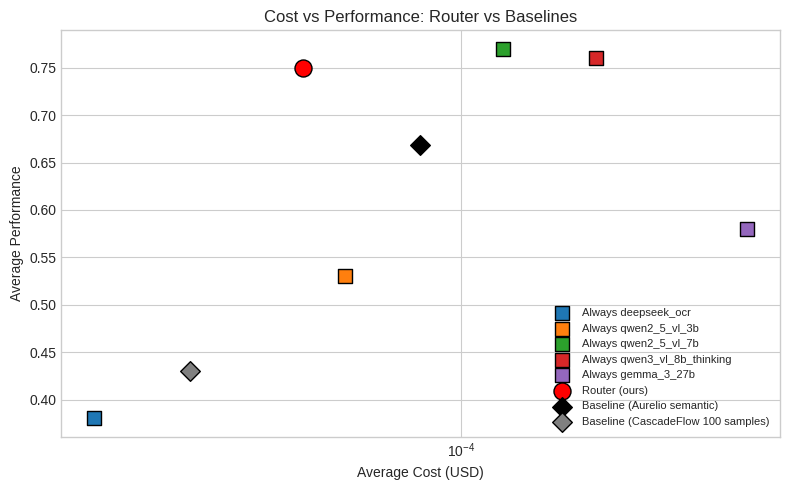

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

policies = [
    {"policy": "Always deepseek_ocr",         "mean_cost": 2.0e-05,  "mean_perf": 0.38},
    {"policy": "Always qwen2_5_vl_3b",        "mean_cost": 6.0e-05,  "mean_perf": 0.53},
    {"policy": "Always qwen2_5_vl_7b",        "mean_cost": 1.2e-04,  "mean_perf": 0.77},
    {"policy": "Always qwen3_vl_8b_thinking", "mean_cost": 1.8e-04,  "mean_perf": 0.76},
    {"policy": "Always gemma_3_27b",          "mean_cost": 3.5e-04,  "mean_perf": 0.58},
    {"policy": "Router (ours)",               "mean_cost": 5.0e-05,  "mean_perf": 0.74976},
]

policies.append({
    "policy": "Baseline (Aurelio semantic)",
    "mean_cost": 8.337550693494824e-05,
    "mean_perf": 0.668132908743212,
})

policies.append({
    "policy": "Baseline (CascadeFlow 100 samples)",
    "mean_cost": 3.04194e-05,
    "mean_perf": 0.43,
})

df = pd.DataFrame(policies)

always_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
baseline_colors = ["black", "gray"]

fig, ax = plt.subplots(figsize=(8, 5))

always_idx = 0
baseline_idx = 0

for _, row in df.iterrows():
    policy = row["policy"]

    if policy.startswith("Always"):
        ax.scatter(
            row["mean_cost"], row["mean_perf"],
            marker="s", s=90,
            color=always_colors[always_idx % len(always_colors)],
            edgecolors="k", label=policy
        )
        always_idx += 1

    elif policy.startswith("Baseline"):
        ax.scatter(
            row["mean_cost"], row["mean_perf"],
            marker="D", s=100,
            color=baseline_colors[baseline_idx % len(baseline_colors)],
            edgecolors="k", label=policy
        )
        baseline_idx += 1

    elif "Oracle" in policy:
        ax.scatter(
            row["mean_cost"], row["mean_perf"],
            marker="*", s=220,
            color="gold", edgecolors="k", label=policy
        )

    elif "Router (ours)" in policy:
        ax.scatter(
            row["mean_cost"], row["mean_perf"],
            marker="o", s=150,
            color="red", edgecolors="k", label=policy
        )

ax.legend(loc="lower right", fontsize=8)
ax.set_xlabel("Average Cost (USD)")
ax.set_ylabel("Average Performance")
ax.set_title("Cost vs Performance: Router vs Baselines")
ax.set_xscale("log")

plt.tight_layout()
plt.show()




